# 04 — Phase-wise Batsman Analysis

**Goal**: Analyse batsman performance across Powerplay (1-6), Middle (7-15), Death (16-20) phases.

**Input**: `data/final_processed_data.csv`

**Output**: `data/phase_sr.csv`

**Columns in output**:
`Full Name, match_phase, total_runs, balls_faced, boundaries, wickets, fours, sixes, strike_rate, boundary_pct, wicket_pct, dot_ball_pct, adaptability_index, adaptability_label, playing_role`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from sklearn.preprocessing import MinMaxScaler
import os, warnings
warnings.filterwarnings('ignore')

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
DATA_DIR     = os.path.join(PROJECT_ROOT, 'data')
MODELS_DIR   = os.path.join(PROJECT_ROOT, 'models')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 110})
print('PROJECT_ROOT:', PROJECT_ROOT)

PROJECT_ROOT: c:\Users\yaswa\OneDrive\Desktop\projects\artificial intelligence project


## 1. Load & Prepare

In [2]:
df = pd.read_csv(os.path.join(DATA_DIR, 'final_processed_data.csv'))
for c in ['isFour','isSix','isWicket']: df[c] = df[c].astype(int)
df['isBoundary'] = ((df['isFour']==1)|(df['isSix']==1)).astype(int)
df['is_valid']   = ((df['wides']==0)&(df['noballs']==0)).astype(int)
df['match_phase'] = df['oversActual'].apply(
    lambda o: 'Powerplay' if o<=6 else ('Middle' if o<=15 else 'Death'))
print(f"Loaded {len(df):,} deliveries | {df['Full Name'].nunique()} batsmen")
print(df['match_phase'].value_counts())

Loaded 33,029 deliveries | 462 batsmen
match_phase
Middle       15198
Powerplay    10790
Death         7041
Name: count, dtype: int64


## 2. Compute Phase Statistics

In [3]:
valid = df[df['is_valid']==1].copy()

phase_sr = valid.groupby(['Full Name','match_phase']).agg(
    total_runs  =('run','sum'),
    balls_faced =('run','count'),
    boundaries  =('isBoundary','sum'),
    wickets     =('isWicket','sum'),
    fours       =('isFour','sum'),
    sixes       =('isSix','sum')
).reset_index()

phase_sr['strike_rate']  = (phase_sr['total_runs']/phase_sr['balls_faced']*100).round(2)
phase_sr['boundary_pct'] = (phase_sr['boundaries']/phase_sr['balls_faced']*100).round(2)
phase_sr['wicket_pct']   = (phase_sr['wickets']/phase_sr['balls_faced']*100).round(2)

dot = (valid.groupby(['Full Name','match_phase'])
           .apply(lambda x: (x['run']==0).mean()*100)
           .reset_index(name='dot_ball_pct'))
phase_sr = phase_sr.merge(dot, on=['Full Name','match_phase'], how='left')
phase_sr['dot_ball_pct'] = phase_sr['dot_ball_pct'].round(2)

print("phase_sr shape:", phase_sr.shape)
phase_sr.head(6)

phase_sr shape: (940, 12)


,Full Name,match_phase,total_runs,balls_faced,boundaries,wickets,fours,sixes,strike_rate,boundary_pct,wicket_pct,dot_ball_pct
0,AB de Villiers,Death,54,18,8,1,1,7,300.00,44.44,5.56,11.11
1,AB de Villiers,Middle,51,36,5,2,3,2,141.67,13.89,5.56,25.00
2,AB de Villiers,Powerplay,6,7,1,0,1,0,85.71,14.29,0.00,57.14
3,Aamir Kaleem,Middle,0,5,0,2,0,0,0.00,0.00,40.00,100.00
4,Aaron Finch,Death,27,16,3,2,2,1,168.75,18.75,12.50,12.50
5,Aaron Finch,Middle,89,91,8,3,6,2,97.80,8.79,3.30,36.26


## 3. Adaptability Index (per phase row)

High SR + High boundary% + Low dot ball% = High adaptability

In [4]:
scaler = MinMaxScaler()
phase_sr['sr_norm']    = scaler.fit_transform(phase_sr[['strike_rate']])
phase_sr['bdry_norm']  = scaler.fit_transform(phase_sr[['boundary_pct']])
phase_sr['dot_norm']   = scaler.fit_transform(phase_sr[['dot_ball_pct']])

phase_sr['adaptability_index'] = (
    0.50 * phase_sr['sr_norm'] +
    0.30 * phase_sr['bdry_norm'] +
    0.20 * (1 - phase_sr['dot_norm'])
).round(3)

phase_sr['adaptability_label'] = pd.cut(
    phase_sr['adaptability_index'],
    bins=[-0.001,0.33,0.66,1.0], labels=['Low','Moderate','High'])

# Attach playing role
role_map = (df.groupby('Full Name')['Batsman_Playing_Role']
              .agg(lambda x: x.mode().iloc[0] if len(x.mode()) else None).to_dict())
phase_sr['playing_role'] = phase_sr['Full Name'].map(role_map)

# Drop normalisation helpers
phase_sr.drop(columns=['sr_norm','bdry_norm','dot_norm'], inplace=True)

print("Adaptability distribution:")
print(phase_sr['adaptability_label'].value_counts())

Adaptability distribution:
adaptability_label
Low         701
Moderate    233
High          6
Name: count, dtype: int64


## 4. Save

In [5]:
out = os.path.join(DATA_DIR, 'phase_sr.csv')
phase_sr.to_csv(out, index=False)
print(f"Saved -> {out}  ({len(phase_sr)} rows x {len(phase_sr.columns)} cols)")

Saved -> c:\Users\yaswa\OneDrive\Desktop\projects\artificial intelligence project\data\phase_sr.csv  (940 rows x 15 cols)


## 5. Visualisations

In [6]:
# Top 10 by mean SR
top10 = (phase_sr[phase_sr['balls_faced']>=20]
         .groupby('Full Name')['strike_rate'].mean()
         .nlargest(10).index.tolist())
plot = phase_sr[phase_sr['Full Name'].isin(top10)].copy()
plot['match_phase'] = pd.Categorical(plot['match_phase'],['Powerplay','Middle','Death'],ordered=True)
plot.sort_values(['Full Name','match_phase'],inplace=True)

fig = px.bar(plot, x='Full Name', y='strike_rate', color='match_phase', barmode='group',
             title='Top 10 Batsmen — Phase-wise Strike Rate',
             color_discrete_sequence=['#2ecc71','#e67e22','#e74c3c'])
fig.update_layout(xaxis_tickangle=-30)
fig.show()

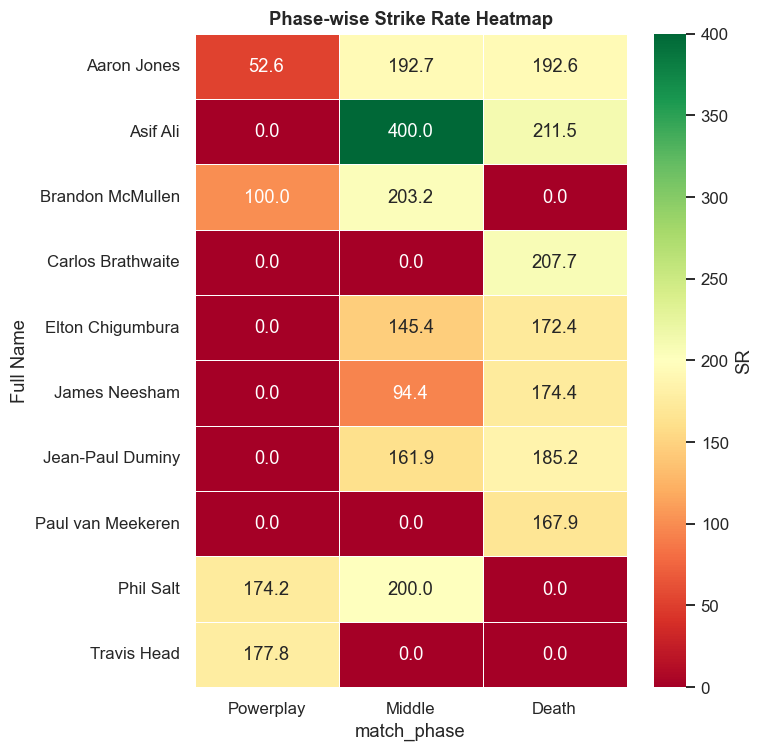

In [7]:
# Phase SR heatmap
pivot = (phase_sr[phase_sr['Full Name'].isin(top10)]
         .pivot_table('strike_rate',index='Full Name',columns='match_phase')
         .fillna(0)[['Powerplay','Middle','Death']])
plt.figure(figsize=(7,7))
sns.heatmap(pivot,annot=True,fmt='.1f',cmap='RdYlGn',linewidths=0.4,cbar_kws={'label':'SR'})
plt.title('Phase-wise Strike Rate Heatmap',fontweight='bold')
plt.tight_layout(); plt.show()

In [8]:
# Boundary % phase bars
fig = px.bar(plot, x='Full Name', y='boundary_pct', color='match_phase', barmode='group',
             title='Phase-wise Boundary % — Top 10',
             color_discrete_sequence=['#2ecc71','#e67e22','#e74c3c'])
fig.update_layout(xaxis_tickangle=-30); fig.show()

In [9]:
# Dot ball box by phase
fig = px.box(phase_sr[phase_sr['balls_faced']>=15], x='match_phase', y='dot_ball_pct',
             color='match_phase', points='outliers',
             category_orders={'match_phase':['Powerplay','Middle','Death']},
             color_discrete_sequence=['#2ecc71','#e67e22','#e74c3c'],
             title='Dot Ball % Distribution by Phase')
fig.show()

In [10]:
# Adaptability by playing role
ra = (phase_sr[phase_sr['balls_faced']>=15]
      .groupby('playing_role')['adaptability_index'].mean()
      .sort_values(ascending=False).reset_index())
fig = px.bar(ra, x='playing_role', y='adaptability_index',
             color='adaptability_index', color_continuous_scale='Blues',
             title='Avg Adaptability by Playing Role',
             text=ra['adaptability_index'].round(3))
fig.update_traces(textposition='outside')
fig.update_layout(xaxis_tickangle=-30,coloraxis_showscale=False); fig.show()

In [11]:
# Radar chart per batsman
def radar_chart(name):
    bat = phase_sr[phase_sr['Full Name'].str.contains(name,case=False,na=False)]
    if bat.empty: print(f"Not found: {name}"); return
    fig = go.Figure()
    for _, row in bat.iterrows():
        fig.add_trace(go.Scatterpolar(
            r=[row['strike_rate']/2, row['boundary_pct'], row['adaptability_index']*100],
            theta=["SR/2","Boundary%","Adaptability x100"],
            fill='toself', name=row['match_phase']))
    player = bat['Full Name'].iloc[0]
    fig.update_layout(polar=dict(radialaxis=dict(visible=True)),
                      title=f"Phase Radar — {player}")
    fig.show()
radar_chart("Virat Kohli")
radar_chart("Rohit Sharma")